<h1><center>Laboratorio 6: ¿A cuanto la casa 🏡?</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Agustin Eduardo Gonzalez Hidalgo
- Nombre de alumno 2: Vicente Ignacio Thiele Muñoz

### **Link de repositorio de GitHub:** `https://github.com/elvixooo/Laboratorios-MDS7202`


## Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

### Objetivos principales del laboratorio

- Aplicar los conocimientos de preprocesamiento, feature extraction y regresión vistos hasta el momento
- Calcular, aplicar e interpretar métricas de regresión
- Mostrar comprensión sobre el fenómeno de sobreajuste y las implicancias que este tiene, así como formas de evitarlo


El laboratorio deberá ser desarrollado con las herramientas de scikit-learn, incluyendo el uso de pipelines

## Descripción del laboratorio.

Usted acaba de ser contratado por la gran empresa inmobiliaria chilena ***TasAi Ltda.*** Esta empresa maneja una parte importante de las propiedades de Santiago, y buscan aumentar sus ventas mediante un **modelo de pricing** que optimice el valor de venta de las propiedades. Para esto, le han encomendado la tarea de liderar un equipo multidisciplinario de analistas, científicos e ingenieros de datos para analizar datos de características de viviendas de santiago de Chile y sus precios y así poder predecir el valor de venta.

## 1. Pipeline predictivo

### 1.1 EDA [1 ptos]

Don ElIas, CEO de _Tasai_ le presenta a su equipo, los mejores **Data Engineers** de la empresa, quienes mediante técnicas avanzadas de web scrapping de sitios inmobiliarios han logrado construir una base de datos con los precios de venta de viviendas y diversas características de estas, presentes en el archivo `"Precios Casas RM.csv"`. Los data engineers confeccionaron una documentación del dataset, la cual se encuentra en el archivo [documentacion_dataset.md](.\documentacion_dataset.md)

Don ElIas le indica que desean optimizar el modelo de **pricing** de _Tasai_. Para esto, debe utilizar de los datos obtenidos por los data engineers para crear un **modelo predictivo** que permita predecir el precio de venta final de la propiedad en pesos chilenos, presentes en la columna `Price_CLP`.

Su primera tarea será explorar el dataset para entender sus variables y entender cómo procesarlas para entrenar el modelo. Para esto deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Ejecutar la función `profile_dataframe` con el dataframe
- Responder las preguntas que encontrará al final de la secciónn respecto a las distribuciones

In [4]:
import pandas as pd

df = pd.read_csv("Precios Casas RM.csv")

In [5]:
import missingno as msno
import plotly.express as px
from IPython.display import Markdown, display
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_dataframe(df, n_samples=1000, random_state=42):
    display(Markdown("# Analisis columnas"))
    display(Markdown("## Descripcion variables"))
    display(df.describe())
    for col in df.columns:
        serie = df[col].copy()

        profile = pd.Series(dtype="object")
        profile["Type"] = serie.dtype
        profile = pd.concat([profile, serie.describe()])

        # profile = pd.Series([])

        if is_numeric_dtype(serie):
            profile["Negative"] = (serie < 0).sum()
            profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
            profile["Zeros"] = (serie == 0).sum()
            profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
            profile["Kurt"] = serie.kurt()
            profile["Skew"] = serie.skew()

        profile[" "] = " "  # espacio

        profile["Missing cells"] = serie.isnull().sum()
        profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
        profile["Duplicate rows"] = serie.duplicated(False).sum()
        profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
        profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

        # profile = pd.concat([profile, description])

        profile = profile.rename(
            index={
                "count": "Number of observations",
                "mean": "Mean",
                "std": "Std",
                "min": "Min",
                "max": "Max",
                "unique": "Unique",
                "top": "Top",
                "freq": "Freq",
            }
        )

        if is_numeric_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}", nbins=48)

        elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

        else:
            count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
            fig = px.bar(
                x=count[serie.name].astype(str),
                y=count["Count"],
                title=f"100 Most common categories of {serie.name}",
            )
        display(Markdown(f"## {serie.name} Profile"))
        display(profile)
        fig.show()

    display(Markdown("# Analisis de nulos"))
    display(Markdown("## Nulos por columna"))
    display(df.isna().sum())
    display(Markdown("## Visualizacion de nulos"))
    msno.matrix(df)
    display(Markdown("## Correlacion de nulidad"))
    msno.heatmap(df)

# Analisis columnas

## Descripcion variables

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,7.779000e+03,7779.000000,7.779000e+03,7779.000000,7714.000000,7533.000000,7571.000000,5489.000000,7.779000e+03
mean,3.642481e+08,10234.571153,4.536091e+05,3.994087,2.653746,229.923669,807.919826,2.980506,9.910828e+06
std,3.868810e+08,10870.491584,4.817945e+05,1.622821,1.465103,1676.898812,9050.893115,17.749384,2.046317e+06
min,2.085000e+03,0.000000,3.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.213620e+06
25%,1.200000e+08,3372.000000,1.494400e+05,3.000000,2.000000,85.000000,129.500000,1.000000,8.563078e+06
50%,2.050000e+08,5760.000000,2.552930e+05,4.000000,2.000000,128.000000,210.000000,2.000000,1.054807e+07
75%,4.911420e+08,13800.000000,6.116340e+05,5.000000,3.000000,200.000000,443.000000,3.000000,1.152463e+07
max,5.516450e+09,155000.000000,6.869801e+06,27.000000,29.000000,120000.000000,678000.000000,1269.000000,1.234149e+07


## Price_CLP Profile

Type                                 int64
Number of observations              7779.0
Mean                      364248117.632086
Std                       386880986.221857
Min                                 2085.0
25%                            120000000.0
50%                            205000000.0
75%                            491142000.0
Max                           5516450000.0
Negative                                 0
Negative (%)                         0.0 %
Zeros                                    0
Zeros (%)                            0.0 %
Kurt                             14.312728
Skew                              2.800394
                                          
Missing cells                            0
Missing cells (%)                    0.0 %
Duplicate rows                        6680
Duplicate rows (%)                 85.87 %
Total size in memory           62364 bytes
dtype: object

...

# Analisis de nulos

## Nulos por columna

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms            0
Baths           65
Built Area     246
Total Area     208
Parking       2290
id               0
dtype: int64

## Visualizacion de nulos

## Correlacion de nulidad

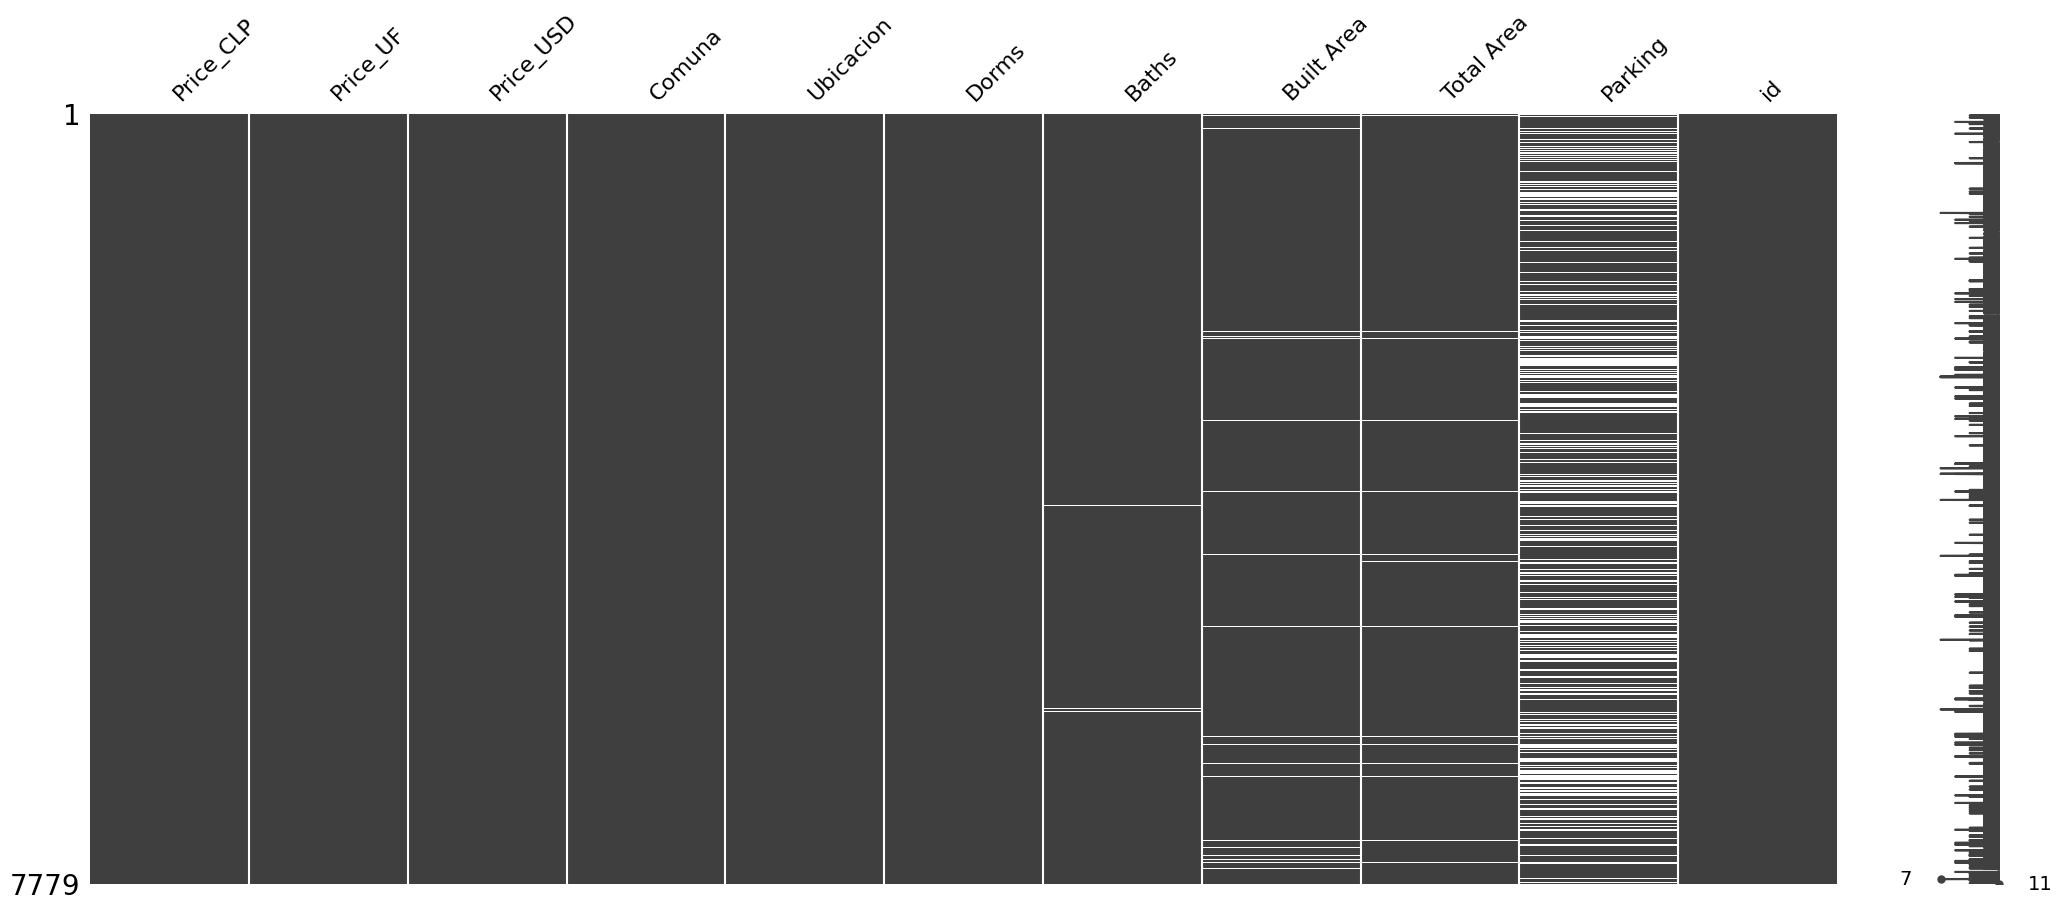

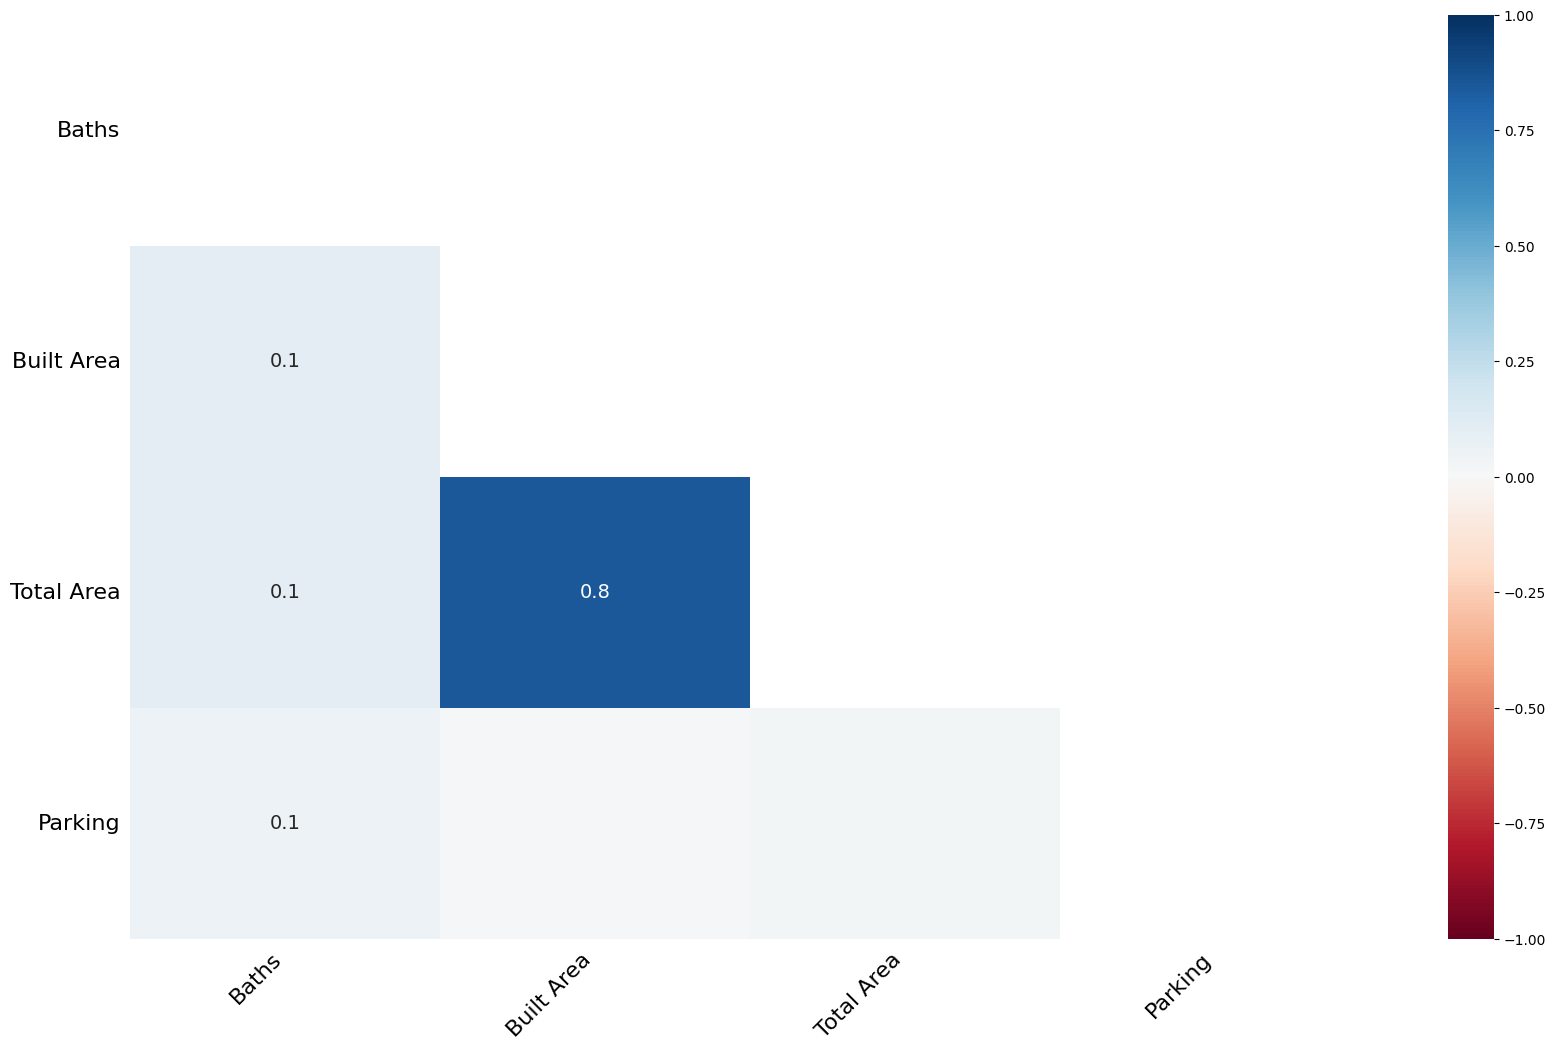

In [6]:
# Inserte acá su código
profile_dataframe(df)

Responda las siguientes preguntas (0.2 pts c/u):

1. ¿Cuál es la distribución de la variable objetivo `Price_CLP` en cuanto a tipo de distribución y rangos?
2. Analice las variables categóricas según qué tan útiles son para modelos de machine learning. ¿Qué columnas utilizaría como features y por qué?
3. Para cada variable con nulos, mencione si son nulos porque el dato **no está disponible**, **no aplica** o si realmente **representan un valor determinado**. Pista: considere los rangos observados de cada variable y analice si tiene sentido con el significado de estas presente en la [documentación](.\documentacion_dataset.md).
4. ¿Debería utilizar la columna `id` como feature para entrenar el modelo? ¿Por qué?
5. ¿Se observan valores atípicos? ¿Cuales son?

`Escriba sus respuestas acá:`

1. Podemos notar que la distribución no es de tipo normal, en cambio tenemos una distribución que tiene un skew alto, de 2.8 aprox. Lo cual se ve reflejado en su forma que concentra valores en el principio de la distribución y van disminuyendo los valores de la frecuencia a lo largo. Y también vemos un valor de kurt grande, de 14.3. Esto se nota en el peak que tiene la distribución, que separa mucho de los otros valores en frecuencia. Los rangos están en escala de miles de millones de pesos chilenos, en donde el valor minimo corresponde a 2.085 y el máximo corresponde a 5.516.450.000.

2. En el dataframe tenemos 2 variables categoricas, Comuna y Ubicación, que corresponden a variables de tipo string. Comuna corresponde a la comuna en la que se encuentra la casa y Ubicación es la ubicación más específica de la casa. En cuanto a los valores resultantes podemos notar que se repiten valores entre las dos variables y tampoco existen valores nulos en las columnas. En este caso nos quedamos con Comuna por su utilidad en modelos de machine learning, dado que presenta valores estandarizados para nombrar a las comunas y son un conjunto definido, y limitado por el numero de comunas exitentes, en cambio Ubicación tiene valores como Noespecifica, Venta, LasCondes y Lascondes, por lo que hay más ruido de por medio y eso puede afectar al modelo de machine learning, esto esta dado por la naturaleza de los datos, ya que la ubicación tiene mucha más libertad y esa nos da más información, pero a la vez no es lo mejor para un modelo de machine learning, que no sabe diferenciar entre si ubicación es una comuna, una calle o la misma comuna repetida con otro nombre.

3. Las variables que tienen nulos son Baths, Build Area, Total Area y Parking. Baths tiene pocos nulos (0.84%), lo cual debe corresponder a que el dato no esta disponible, ya que consideramos que una casa no puede no tener baños. Build Area en este caso los nulos representan un 3.16%, esto también también lo consideramos un error de tipo no disponible, ya que al ser un dataframe de casas, es imposible que no se tenga el Build Area de la casa en cuestión. Total Area tiene un porcentaje de 2.67% de nulos, y también entra en la categoria de valores no disponibles, ya que no puedo no existir un Total Area. Por último tenemos Parking, que tiene un 29.44% de nulos, y en este caso consideramos que valores nulos si representan algo, en este caso una casa que no tiene estacionamiento, ya que por lo que vimos en su profile no tiene valores menos a 1, por lo que no hay valores iguales a 0, y eso se suple con valores nulos.

4. No, no lo vamos a usar, porque el id representa a la propiedad en especifico y nosotros no necesitamos ese valor para entrenar un modelo predictivo que permita predecir el precio de venta final de la propiedad en pesos chilenos, por lo tanto es una etiqueta que no va al caso.

5. En Price_CLP, Price_UF y Price_USD, tenemos un valor atipico en cuanto al menor valor, ya que en pesos chilenos estariamos diciendo que se vende una casa a 2.085 pesos, lo cual es muy bajo para una casa, en Ubicacion hay valores como Noespecifica, Venta, LasCondes y lascondes, Vendocasapuentealto, que no son valores validos para una ubicación o que pueden traer errores, como calles sin numeración. En Baths tenemos un valor máximo de 29 baños, lo cual excede a la cantidad máxima de Dorms (27), esto nos llama la atención, de que puedan haber más baños máximos que dormitorios máximos. En Built Area, hay valores minimos de 1 metro cuadrado, lo cual es dificil de imaginar en Chile y lo mismo para Total Area, que tiene 1 metro cuadrado como valor minimo. En Parking, hay un valor inusual en el maximo, en donde se tienen 1.269 estacionamientos para una casa, lo cual es dificil de conceptualizar, considerando que solo son casas.

### 1.2 Preparación de datos [0.75 ptos]

Cree la función `preparacion_de_datos` la cual debe realizar toda la carga y preparación inicial de los datos que no corresponde ir en el pipeline de preprocesamiento. En esta función, ud. deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Eliminar duplicados usando las columnas que estime conveniente
- Eliminar filas nulas, sólo considerando las columnas que su EDA reveló que corresponde eliminar nulos en esas columnas (para algunas puede tener más sentido imputarlas)
- Eliminar valores atípicos (Opcional). Puede aplicar criterio personal a lo que considera atípico.
- Separación del target
- Holdout

Ejecute esta función para obtener ``X_train``, ``X_test``, ``y_train``, ``y_test`` (0.5 ptos)

Luego, justifique su preparación de datos al final de la sección (0.25 ptos)

In [7]:
from sklearn.model_selection import train_test_split


def preparacion_de_datos():
    df = pd.read_csv("Precios Casas RM.csv")

    df.drop_duplicates(subset=["id"])

    df.dropna(subset=["Baths", "Built Area", "Total Area"])
    df.fillna({"Parking": 0}, inplace=True)

    df = df[df["Total Area"] > 1]
    df = df[df["Built Area"] > 1]
    df = df[df["Price_UF"] > 1]
    df = df[df["Dorms"] < 27]
    df = df[df["Baths"] < 29]
    df = df[df["Parking"] < 60]

    X = df.drop(columns=["Price_CLP"])
    y = df["Price_CLP"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=25)
    return X_train, X_test, y_train, y_test

In [8]:
x_train, x_test, y_train, y_test = preparacion_de_datos()

Justificar su preparación de datos.
- ¿Qué columnas usó para eliminar nulos y por qué?

Usamos 3 columnas para eliminar nulos: Baths, Built Area y Total Area, ya que estos valores nulos significan valores no disponibles, por lo que deben ser eliminados, en cambio Parking tiene valores nulos, pero con interpretación, ya que estos valores nulos, pueden ser posibles y se reemplazan por 0.

- ¿Qué proporción de los datos usó para test y por qué?

En este caso usamos un 33% de los datos, ya que es lo que se suele hacer en la literatura y también por lo mostrado en clases. Así tenemos una proporción de 2/3 y 1/3 respectivamente.

### 1.3 Preprocesamiento [1 ptos]

Confeccione un `ColumnTransformer` que realice el preprocesamiento de los datos (0.75 ptos). Se recomienda fuertemente basarse en sus observaciones del EDA. El column transformer deberá realizar: 
- Selección de columnas
- Imputación de valores nulos, si los hay
- Escalamiento de variables numéricas
- Encoding de variables categóricas con `one hot encoding`.
- No eliminar la variable `Comuna`

Luego, debe responder las preguntas al final de la sección donde se pide justificar su preprocesamiento. (0.25 ptos)

In [9]:
# Inserte su código aquí
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ct = ColumnTransformer(
    transformers=[
        ("seleccion", "drop", ["id", "Ubicacion"]),
        ("imputacion", SimpleImputer(fill_value=0), ["Parking"]),
        (
            "escalado",
            StandardScaler(),
            ["Price_UF", "Price_USD", "Dorms", "Baths", "Built Area", "Total Area"],
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore"), ["Comuna"]),
    ]
)

Justificar su preprocesamiento.
- ¿Qué columnas eliminó y por qué?

- ¿Por qué escaló los features de esta forma?

- ¿Qué valor(es) usó para imputación y por qué?

`Escriba sus respuestas acá:`

- Eliminamos id y Ubicación, ya que como analizamos anteriormente, id no aporta información relevante al modelo de machine learning y Ubicacion no es una columna que entregue información consistente, en comparacion a Comuna.

- Porque la mayoria de los features se mueven entre valores diferentes y de distintos valores, por lo que un escalador estandar para todos queda bien.

- Se imputo valores de 0 para Parking ya que estos representan una posibilidad real en los datos.

### 1.4 Entrenamiento de modelo [0.25 ptos]

A continuación debe crear el `Pipeline` final que incluye el preprocesamiento y el modelo. Para esto usted debe:
- Elegir uno de los modelos vistos en clase: `Regresión lineal`, `Ridge`, `LASSO`, `ElasticNet`
- Crear un pipeline que incluya el preprocesamiento obtenido en la sección anterior y el modelo elegido con hiperparámetros a su elección
- Entrenar pipeline en el dataset de entrenamiento

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

pipelineV1 = Pipeline(steps=[("preprocesamiento", ct), ("modelo", LinearRegression())])

pipelineV1.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('seleccion', ...), ('imputacion', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

### 1.5 Evaluación [1 ptos]

Finalmente llegó el momento de evaluar la capacidad predictiva de su modelo **en datos de test** y demostrarle a don Elias que su trabajo agrega valor a _Tasai_. Para esto, usted deberá:
1. Crear la función `evaluate_model` que reciba el pipeline y los datos de test, realice predicciones y luego calcule las métricas **RMSE**, **MAE** (mean absolute error) y **$R^2$** tanto en datos de **train** como datos de **test**, diferenciándolos mediante prints. (0.2 ptos)

In [11]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


def evaluate_model(pipeline, X_train, X_test, y_train, y_test):
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    metrics = {
        "RMSE Train": root_mean_squared_error(y_train, y_train_pred),
        "RMSE Test": root_mean_squared_error(y_test, y_test_pred),
        "MAE Train": mean_absolute_error(y_train, y_train_pred),
        "MAE Test": mean_absolute_error(y_test, y_test_pred),
        "R2 Train": r2_score(y_train, y_train_pred),
        "R2 Test": r2_score(y_test, y_test_pred),
    }

    return metrics

2. Crear la función `complete_pipeline_v1` que utilice las funciones y objetos definidos anteriorment (`preparacion_de_datos`, el pipeline y `evaluate_model`) de forma que al ejecutarlo se obtengan las métricas del modelo (0.2 ptos)

In [12]:
def complete_pipeline_v1():
    metrics = evaluate_model(pipelineV1, x_train, x_test, y_train, y_test)
    return metrics

In [13]:
complete_pipeline_v1()

{'RMSE Train': 3377.595259647837,
 'RMSE Test': 3300.3325050784265,
 'MAE Train': 2091.3270774883636,
 'MAE Test': 2015.3420675030645,
 'R2 Train': 0.9999999999249729,
 'R2 Test': 0.9999999999264095}

3. Responder las siguientes preguntas (0.15 ptos c/u)
- ¿Qué tan bien el modelo predice el precio de la vivienda? Justifique su respuesta basándose en las 3 métricas obtenidas (debe decir algo de cada métrica)

Bastante bien, ya que las metricas RMSE, MAE y R2 dan buenos resultados, RMSE nos da el error con una escala cuadratica y nos dice que es de 3.300 aprox para train y test, lo cual nos dice que hay una desviación baja del precio original en la predicción. MAE nos da el error usando un valor absoluto y nos dice el promedio de las diferencias absolutas, así tenemos que el promedio de las diferencias absolutas de precios de las viviendas corresponden a 2.100 aprox para train y test, lo cual nos da a entender que la predicción es buena porque la desviación es baja. Y R2 es cercano a 1 por lo que esta bastante bien, ya que R2 representa una proporción de la varianza del precio de la vivienda que es predecible a partir de las caracteristicas de la vivienda.

- ¿Qué diferencia haría elegir un modelo que optimice cada una de las 3 métricas?

Tomar un modelo que pueda optimizar las 3 metricas traeria mejores valores para estas metricas, en este caso para RMSE y MAE un mejor valor es un valor más bajo, por lo que esos valores disminuirian, en cambio para R2, mientras más cercano a 1 es mejor, y en este caso ya es bastante cercano, pero podria mejorar.

- ¿Qué factores pueden haber influido en el desempeño del modelo? Discuta posibles fuentes de error

La cantidad de valores del dataset no son muchos, por lo que eso puede llevar a un sobreajuste de los datos, por eso tenemos valores de R2 tan buenos. Y puede introducirse un posible error por no tener una ubicación precisa, que nos lleva a tener un sesgo alto.

- Compare las métricas obtenidas con datos de entrenamiento y test. ¿Hubo sobreajuste? Justifique

No hubo sobreajuste, ya que los valore de train y test son similares entre sí para cada métrica.

## 2. Análisis de sobreajuste

Don Elias está contento con sus resultados... pero no tanto. Él piensa que el modelo puede mejorar aún más, por lo que ha decidido contactar a **consultores externos** de la empresa _SuperAI_ para complementar su equipo de trabajo. Los consultores de _SuperAI_ le comentan que consideran que el tratamiento de datos ha sido **subóptimo** debido principalmente a que produce **sobreajuste** y que creen que pueden mejorar el modelo incluyendo datos adicionales sobre las **características socioeconómicas** de las comunas para mitigar el sobreajuste.

### 2.1 Incorporación de datos adicionales [0.5 ptos]

Los consultores de _SuperAI_ le han proporcionado un dataset adicional presente en el archivo `ingresos_por_comuna_2024.xlsx`, el cual contiene la población y el porcentaje de personas en situación de pobreza por comuna. Le encargan **cruzar** estos datos con el dataset principal para incorporar esta información del porcentaje de pobreza en la predicción.

Para esto, usted deberá crear la función `preparacion_de_datos_2`, la cual es una copia de `preparacion_de_datos` pero que incluye la carga del dataset `ingresos_por_comuna_2024.xlsx` y merge con `Precios Casas RM.csv`. Considerar:
- Sólo incorporar la columna `Porcentaje de personas en situacion de pobreza de ingresos 2024` en el dataset
- Renombrar la columna a un nombre más corto
- No modificar nada más de la función original `preparacion_de_datos`

In [23]:
def preparacion_de_datos_2():
    df = pd.read_csv("Precios Casas RM.csv")
    df_comunas = pd.read_excel("ingresos_por_comuna_2024.xlsx")

    df_comunas = df_comunas[
        ["Nombre comuna", "Porcentaje de personas en situacion de pobreza de ingresos 2024"]
    ].rename(
        columns={
            "Porcentaje de personas en situacion de pobreza de ingresos 2024": "Pobreza_2024",
            "Nombre comuna": "Comuna",
        }
    )

    df = df.merge(df_comunas, on="Comuna", how="left")

    df.drop_duplicates(subset=["id"])
    df.dropna(subset=["Baths", "Built Area", "Total Area"])
    df.fillna({"Parking": 0}, inplace=True)

    df = df[df["Total Area"] > 1]
    df = df[df["Built Area"] > 1]
    df = df[df["Price_UF"] > 1]
    df = df[df["Dorms"] < 27]
    df = df[df["Baths"] < 29]
    df = df[df["Parking"] < 60]

    X = df.drop(columns=["Price_CLP"])
    y = df["Price_CLP"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=25)
    return X_train, X_test, y_train, y_test

### 2.2 Adaptación del pipeline [0.5 ptos]

Como su función de carga de datos incorpora una nueva columna, se ve obligado a adaptar el resto del pipeline. Adicionalmente, los consultores de _SuperAI_ creen que el modelo todavía puede mejorar, por lo que le solicitan utilizar un procesamiento distinto de la columna `Comuna`. Esta vez, en vez de utilizar **One hot encoding** en la variable **comuna** (o de eliminar la columna si hizo esto), deberá utilizar **Target encoding**. El target encoding es una técnica de feature engineering para procesas variables categóricas donde la variable categórica se remplaza por el promedio de la variable objetivo. Es decir, en este caso se remplaza la comuna por el valor promedio de las propiedades de esa comuna.

Su objetivo en esta sección es crear la función `complete_pipeline_v2` de igual manera que la sección anterior, con las siguientes modificaciones:
- Incluir la nueva variable dentro de las columnas del preprocesamiento numérico
- Utilizar `TargetEncoder(target_type='continuous')` para procesar la variable categórica **comuna**
- Crear la función `complete_pipeline_v2` usando `preparacion_de_datos_2`, el nuevo pipeline y `evaluate_model` (no debería necesitar modificaciones)


In [ ]:
from category_encoders import TargetEncoder

x_train, x_test, y_train, y_test = preparacion_de_datos_2()

ct2 = ColumnTransformer(
    transformers=[
        ("seleccion", "drop", ["id", "Ubicacion"]),
        ("imputacion", SimpleImputer(fill_value=0), ["Parking"]),
        (
            "escalado",
            StandardScaler(),
            ["Price_UF", "Price_USD", "Dorms", "Baths", "Built Area", "Total Area", "Pobreza_2024"],
        ),
        ("onehot", TargetEncoder(), ["Comuna"]),
    ]
)

pipelineV2 = Pipeline(steps=[("preprocesamiento", ct2), ("modelo", LinearRegression())])

pipelineV2.fit(x_train, y_train)


def complete_pipeline_v2():
    metrics = evaluate_model(pipelineV2, x_train, x_test, y_train, y_test)
    return metrics

### 2.3 Comparación de resultados [0.5 ptos]

Finalmente, habiendo construido 2 pipelines diferentes para abordar el mismo problema, don Elias está ansioso por ver los resultados.

- Ejecutar `complete_pipeline_v1` y `complete_pipeline_v2`
- Comparar las métricas y comentar los resultados. ¿Qué modelo considera que le fue mejor?

In [29]:
# Ingresar su código aquí
complete_pipeline_v1()

{'RMSE Train': 3377.595259647837,
 'RMSE Test': 3300.3325050784265,
 'MAE Train': 2091.3270774883636,
 'MAE Test': 2015.3420675030645,
 'R2 Train': 0.9999999999249729,
 'R2 Test': 0.9999999999264095}

In [30]:
complete_pipeline_v2()

{'RMSE Train': 3407.1260085658178,
 'RMSE Test': 3310.96689515975,
 'MAE Train': 2068.123796770356,
 'MAE Test': 1975.3682417623645,
 'R2 Train': 0.9999999999236552,
 'R2 Test': 0.9999999999259345}

`Escriba su respuesta acá:`

Si comparamos las métricas tenemos que los valores de RMSE y R2 son bastante iguales, RMSE es un poco peor en el caso de pipeline V2, pero no es tan significativo, en cambio la mejora de MAE para test si nos entrega un resultado que podemos considerar mejor y por tanto consideramos que le fue mejor a la 2da versión.

### 2.4 Discusión [0.5 ptos]

1. Considerando los resultados obtenidos mencione al menos 2 razones de por qué cree que a uno de los modelos le fue mejor que a otro. ¿Cómo se relaciona con el fenómeno de sobreajuste?

`Escriba su respuesta acá:`

Primero porque tiene más variables a considerar (Pobreza por comuna), lo que hace que no se sobreajuste con tanta facilidad. Y la segunda razon la atribuimos al uso del TargetEncoder para la segunda versión, que ataca mejor el problema que estamos intentando modelar.

2. Determine la cantidad de parámetros (complejidad) de los 2 modelos entrenados usando `pipeline.steps[...]` para obtener el modelo y luego imprimiendo el largo del atributo `coef_`. Luego, considerando las métricas de ambos modelos y la complejidad ¿Qué puede decir sobre el tratamiento de datos del segundo pipeline? Justifique

In [35]:
# Escriba su código aquí
print(len(pipelineV1.steps[1][1].coef_))

58


In [36]:
print(len(pipelineV2.steps[1][1].coef_))

9


`Escriba su respuesta acá:`

El tratamiento de datos del segundo pipeline es menos complejo que el primero, ya que tiene menos cantidad de parametros, y obtiene resultados silimares en las métricas mejorando el MAE, el cual nos da un error en valor absoluto menor. El segundo modelo entiende mejor los datos que modela.